Beach Unstable: 0 year(s)


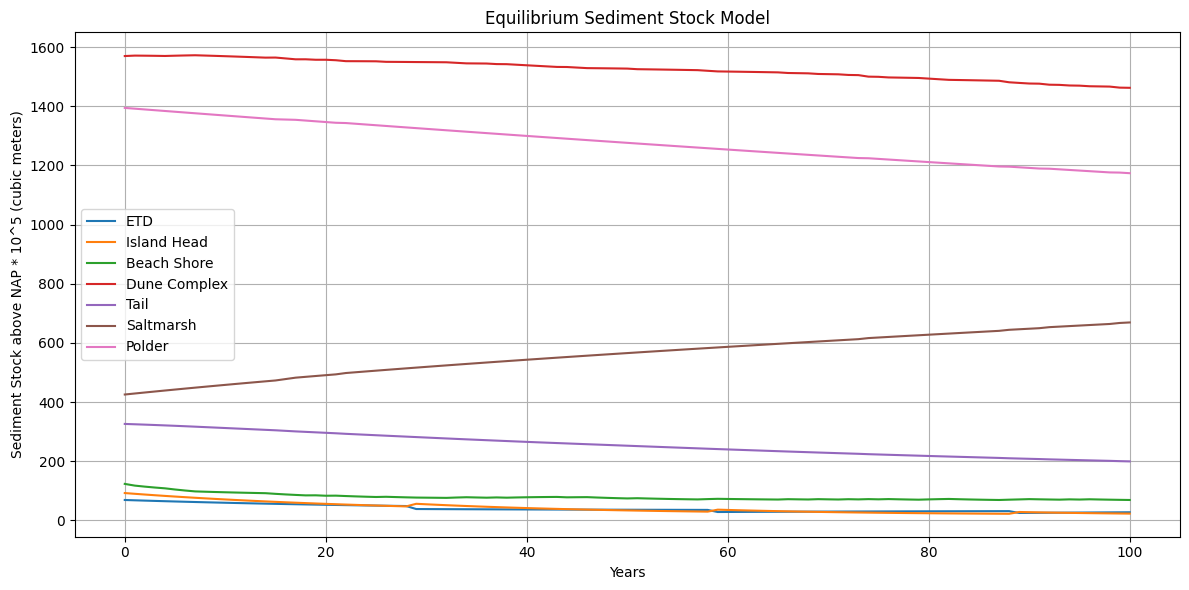

In [6]:
# Import libaries
import matplotlib.pyplot as plt
import random
import numpy as np


# Time steps
time_steps = 101

# Initial sediment stocks based on Ameland (volume based on AHN4)
stocks = {
    "Offshore": 12000,
    "ETD": 70,
    "Island Head": 95,
    "Beach Shore": 130,
    "Dune Complex": 1568,
    "Tail": 327,
    "Saltmarsh": 422,
    "Tidal Basin": 500,
    "Polder": 1397
}
# Areas (in sq meters) of the stock based on Ameland, 1 if area does not apply
stock_areas = {
    "Offshore": 1,
    "ETD": 1,
    "Island Head": 2721624,
    "Beach Shore": 2729134.5,
    "Dune Complex": 12998500.25,
    "Tail": 4713029,
    "Saltmarsh": 7702768.5,
    "Tidal Basin": 1,
    "Polder": 27450395.25
} 

stock_elevation = {
    "Offshore": 1,
    "ETD": 1,
    "Island Head": 1,
    "Beach Shore": 1,
    "Dune Complex": 1,
    "Tail": 1,
    "Saltmarsh": 1,
    "Tidal Basin": 1,
    "Polder": 1
} 

# Store history for plotting
history = {key: [] for key in stocks}
history_elevation = {key: [] for key in stocks}

# Store polder stock for management
polder_original = stocks["Polder"]

# Beach stability setting
SBeach = 1 # if 1 -> stable, 0 -> unstable
instablilty_factor = 1.1 # if eg. 1.25: beach is eroded with 25% more then it is accreting
beach_to_offshore = 0 # needed value to kickstart the model
beach_unstable_count = 0

# Parameters
big_storm_chance = 0.1
small_storm_chance = 0.3
overwash_multiplier = 2
polder_subsidence_rate = 0.003 
etd_shoaling_rate = 0.2  # 20% of ETD sediment moves to Island Head every 30 years
embankment_threshold = 4000
depoldering_value = 2/3
#tot_SLR = 2 #2 meters over 100 years
TSL = np.logspace(0.2,-1,time_steps)
#SLR = np.linspace(0, tot_SLR, time_steps)
dSLR = 0.00

# Simulation loops
for t in range(1, time_steps + 1):
    if stocks["Dune Complex"] > 0:
        # Storm surge event
        big_storm = random.random() < big_storm_chance
        small_storm = random.random() < small_storm_chance
        
        # Flows
        if stocks["Beach Shore"]/4 > beach_to_offshore: # check if there is sediment on the beach
            offshore_to_etd = 1                                                        # Oost et al. (2017)
            offshore_to_beach = 9 #0.05 * stocks["Offshore"]                           # Oost et al. (2017)
            islands_head_to_dune = 0.01 * stocks["Island Head"]
            etd_to_island_head = 0.03 * stocks["ETD"]
            island_head_to_beach = 0.04 * stocks["Island Head"]
            beach_to_dune = 0.03 * stocks["Beach Shore"]
            beach_to_tail = 0.02 * stocks ["Beach Shore"]
            beach_to_offshore = 0.1 * stocks["Beach Shore"] if SBeach else offshore_to_beach * instablilty_factor
            dune_to_saltmarsh = 0.001 * stocks["Dune Complex"] * (overwash_multiplier if big_storm else 1)
            dune_to_polder = 0.001 * stocks["Dune Complex"] * (overwash_multiplier if big_storm else 1)
            dune_to_beach = stocks["Dune Complex"] * (0.001 if small_storm else 0)
            tail_to_offshore = 0.01 * stocks["Tail"]
            tail_to_saltmarsh = 0.001 * stocks["Tail"] * (overwash_multiplier if big_storm else 1)
            tidal_to_saltmarsh = TSL[t-1] #3.5 stocks["Saltmarsh"] * 0.002
            tidal_to_polder = 0 * stocks["Tidal Basin"]
            polder_subsidence = stocks["Polder"]*polder_subsidence_rate   
        else:
            beach_unstable_count += 1
            offshore_to_etd = 1 
            offshore_to_beach = 9 #0.05 * stocks["Offshore"]
            islands_head_to_dune = 0.01 * stocks["Island Head"]
            etd_to_island_head = 0.03 * stocks["ETD"]
            island_head_to_beach = 0.04 * stocks["Island Head"]
            beach_to_dune = 0.03 * stocks["Beach Shore"]
            beach_to_tail = 0.02 * stocks ["Beach Shore"]
            beach_to_offshore = 0.1 * stocks["Beach Shore"] if SBeach else offshore_to_beach * instablilty_factor
            dune_to_saltmarsh = 0.001 * stocks["Dune Complex"] * (overwash_multiplier if big_storm else 1)
            dune_to_polder = 0.001 * stocks["Dune Complex"] * (overwash_multiplier if big_storm else 1)
            dune_to_beach = (stocks["Dune Complex"] * (0.001 if small_storm else 0)) + abs(stocks["Beach Shore"]/4 - beach_to_offshore)*4
            tail_to_offshore = 0.01 * stocks["Tail"]
            tail_to_saltmarsh = 0.001 * stocks["Tail"] * (overwash_multiplier if big_storm else 1)
            tidal_to_saltmarsh = TSL[t-1] #3.5 stocks["Saltmarsh"] * 0.002
            tidal_to_polder = 0 * stocks["Tidal Basin"]
            polder_subsidence = stocks["Polder"]*polder_subsidence_rate
        
        # ETD shoaling event every 30 years
        etd_shoaling = etd_shoaling_rate * stocks["ETD"] if t % 30 == 0 else 0
         
        
        # embankment of Saltmarshes
        if stocks ["Saltmarsh"] > embankment_threshold:
            saltmarsh_to_polder = 2/3*embankment_threshold
            embankment = 1
        else:
            saltmarsh_to_polder = 0
            embankment = 0
        
        # de-embankment of Polder
        subsidence_threshold = stocks["Polder"]/polder_original
        if subsidence_threshold < depoldering_value:
            polder_to_saltmarsh = 2/3*stocks["Polder"]
            de_embankment = 1
        else:
            polder_to_saltmarsh = 0
            de_embankment = 0
        
        # Update stocks
        stocks["Offshore"] += tail_to_offshore - offshore_to_etd - offshore_to_beach
        stocks["ETD"] += offshore_to_etd - etd_to_island_head - etd_shoaling
        stocks["Island Head"] += etd_to_island_head + etd_shoaling - island_head_to_beach - islands_head_to_dune
        stocks["Beach Shore"] += island_head_to_beach - beach_to_dune + offshore_to_beach - beach_to_offshore - beach_to_tail + dune_to_beach
        stocks["Dune Complex"] += beach_to_dune + islands_head_to_dune - dune_to_saltmarsh - dune_to_beach - dune_to_polder
        stocks["Tail"] += beach_to_tail - tail_to_offshore - tail_to_saltmarsh
        stocks["Saltmarsh"] += tidal_to_saltmarsh + polder_to_saltmarsh - saltmarsh_to_polder + dune_to_saltmarsh + tail_to_saltmarsh
        stocks["Tidal Basin"] += -tidal_to_saltmarsh - tidal_to_polder
        stocks["Polder"] += tidal_to_polder - polder_to_saltmarsh - polder_subsidence + saltmarsh_to_polder + dune_to_polder

        # apply SLR
        if dSLR == 0:
            pass
        else:
            for key in stocks:
                if key not in ["Tidal Basin", "Offshore","ETD"]:
                    stock_elevation[key] = (stocks[key]/stock_areas[key])*100000
                    stock_elevation[key] += -dSLR
                    stocks[key] = stock_elevation[key]/100000*stock_areas[key]
                else:
                    pass
                                        
        
        # Record history
        for key in stocks:
            history[key].append(stocks[key])
            history_elevation[key].append(stock_elevation[key])
            
        #update polder stock to new original value
        if de_embankment == 1 or embankment == 1:
            polder_original = stocks["Polder"] 
        else: 
            pass

    else:
        pass
        
# Printing
print('Beach Unstable: '+ str(beach_unstable_count) + ' year(s)')

# Plotting
plt.figure(figsize=(12, 6))
for key in history:
    if key not in ["Tidal Basin", "Offshore"]:
        plt.plot(history[key], label=key)
plt.xlabel("Years")
plt.ylabel("Sediment Stock above NAP * 10^5 (cubic meters)")
plt.title("Equilibrium Sediment Stock Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



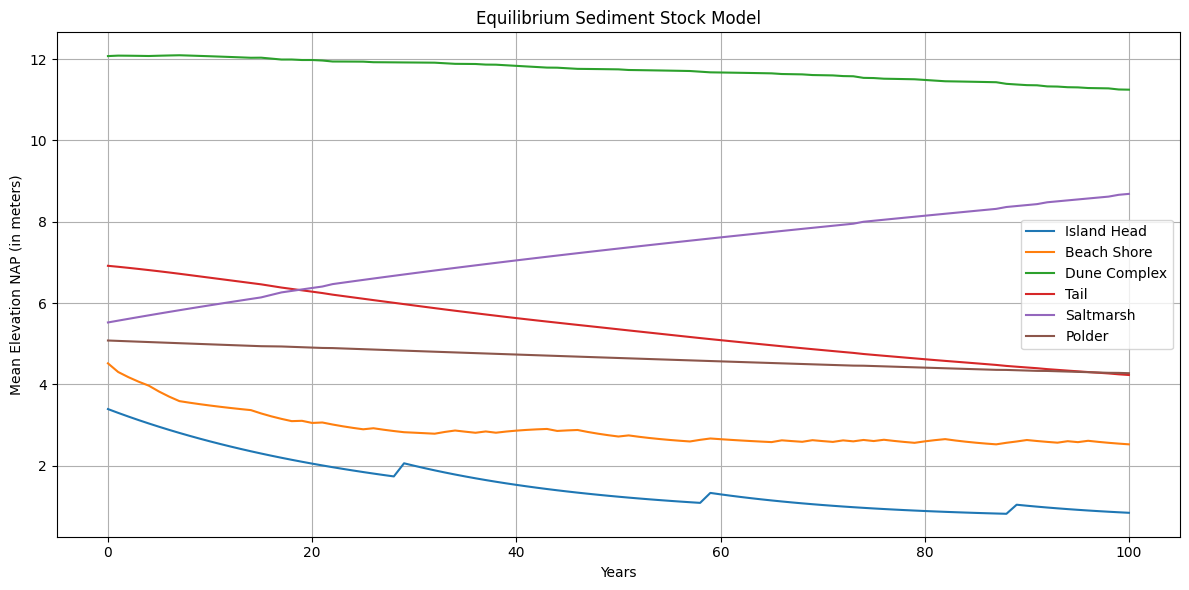

In [7]:
# recalculate to elevation
# Initial area of stocks based on Ameland, 1's if not applicable
Stock_areas = {
    "Offshore": 1,
    "ETD": 1,
    "Island Head": 2721624,
    "Beach Shore": 2729134.5,
    "Dune Complex": 12998500.25,
    "Tail": 4713029,
    "Saltmarsh": 7702768.5,
    "Tidal Basin": 1,
    "Polder": 27450395.25
} 


# Plotting
plt.figure(figsize=(12, 6))
for key in history:
    if key not in ["Tidal Basin", "Offshore","ETD"]:
        pltarea = np.repeat(Stock_areas[key], len(history[key]))
        pltvl = history[key]*np.repeat(100000, len(history[key]))/pltarea
        plt.plot(pltvl, label=key)
        
plt.xlabel("Years")
plt.ylabel("Mean Elevation NAP (in meters)")
plt.title("Equilibrium Sediment Stock Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
S = [12000,70,95,130,1568,327,422,500,1397]
A = [2721624, 2729134, 12998500, 4713029, 7702768, 27450395]

In [8]:
def ESSM(time,S,A,SLR):
        # Time steps
    time_steps = time
    
    # Initial sediment stocks based on Ameland (volume based on AHN4)
    stocks = {
        "Offshore": S[0],
        "ETD":  S[1],
        "Island Head":  S[2],
        "Beach Shore":  S[3],
        "Dune Complex":  S[4],
        "Tail":  S[5],
        "Saltmarsh":  S[6],
        "Tidal Basin":  S[7],
        "Polder":  S[8]
    }
    # Areas of the stock based on Ameland, 1 if area does not apply
    stock_areas = {
        "Offshore": 1,
        "ETD": 1,
        "Island Head": A[0],
        "Beach Shore": A[1],
        "Dune Complex": A[2],
        "Tail": A[3],
        "Saltmarsh": A[4],
        "Tidal Basin": 1,
        "Polder": A[5]
    } 
    
    stock_elevation = {
        "Offshore": 1,
        "ETD": 1,
        "Island Head": 1,
        "Beach Shore": 1,
        "Dune Complex": 1,
        "Tail": 1,
        "Saltmarsh": 1,
        "Tidal Basin": 1,
        "Polder": 1
    } 
    
    # Store history for plotting
    history = {key: [] for key in stocks}
    history_elevation = {key: [] for key in stocks}
    
    # Store polder stock for management
    polder_original = stocks["Polder"]
    
    # Beach stability setting
    SBeach = 1 # if 1 -> stable, 0 -> unstable
    instablilty_factor = 1.1 # if eg. 1.25: beach is eroded with 25% more then it is accreting
    beach_to_offshore = 0 # needed value to kickstart the model
    beach_unstable_count = 0
    
    # Parameters
    big_storm_chance = 0.1
    small_storm_chance = 0.3
    overwash_multiplier = 2
    polder_subsidence_rate = 0.003 
    etd_shoaling_rate = 0.2  # 20% of ETD sediment moves to Island Head every 30 years
    embankment_threshold = 4000
    depoldering_value = 2/3
    #tot_SLR = 2 #2 meters over 100 years
    TSL = np.logspace(0.2,-1,time_steps)
    #SLR = np.linspace(0, tot_SLR, time_steps)
    dSLR = SLR
    t_end = [time_steps] # storing the amount of timesteps
    
    # Simulation loops
    for t in range(1, time_steps + 1):
        if stocks["Dune Complex"] > 0:
            # Storm surge event
            big_storm = random.random() < big_storm_chance
            small_storm = random.random() < small_storm_chance
            
            # Flows
            if stocks["Beach Shore"]/4 > beach_to_offshore: # check if there is sediment on the beach
                offshore_to_etd = 1                                                        # Oost et al. (2017)
                offshore_to_beach = 9 #0.05 * stocks["Offshore"]                           # Oost et al. (2017)
                islands_head_to_dune = 0.01 * stocks["Island Head"]
                etd_to_island_head = 0.03 * stocks["ETD"]
                island_head_to_beach = 0.04 * stocks["Island Head"]
                beach_to_dune = 0.03 * stocks["Beach Shore"]
                beach_to_tail = 0.02 * stocks ["Beach Shore"]
                beach_to_offshore = 0.1 * stocks["Beach Shore"] if SBeach else offshore_to_beach * instablilty_factor
                dune_to_saltmarsh = 0.001 * stocks["Dune Complex"] * (overwash_multiplier if big_storm else 1)
                dune_to_polder = 0.001 * stocks["Dune Complex"] * (overwash_multiplier if big_storm else 1)
                dune_to_beach = stocks["Dune Complex"] * (0.001 if small_storm else 0)
                tail_to_offshore = 0.01 * stocks["Tail"]
                tail_to_saltmarsh = 0.001 * stocks["Tail"] * (overwash_multiplier if big_storm else 1)
                tidal_to_saltmarsh = TSL[t-1] #3.5 stocks["Saltmarsh"] * 0.002
                tidal_to_polder = 0 * stocks["Tidal Basin"]
                polder_subsidence = stocks["Polder"]*polder_subsidence_rate   
            else:
                beach_unstable_count += 1
                offshore_to_etd = 1 
                offshore_to_beach = 9 #0.05 * stocks["Offshore"]
                islands_head_to_dune = 0.01 * stocks["Island Head"]
                etd_to_island_head = 0.03 * stocks["ETD"]
                island_head_to_beach = 0.04 * stocks["Island Head"]
                beach_to_dune = 0.03 * stocks["Beach Shore"]
                beach_to_tail = 0.02 * stocks ["Beach Shore"]
                beach_to_offshore = 0.1 * stocks["Beach Shore"] if SBeach else offshore_to_beach * instablilty_factor
                dune_to_saltmarsh = 0.001 * stocks["Dune Complex"] * (overwash_multiplier if big_storm else 1)
                dune_to_polder = 0.001 * stocks["Dune Complex"] * (overwash_multiplier if big_storm else 1)
                dune_to_beach = (stocks["Dune Complex"] * (0.001 if small_storm else 0)) + abs(stocks["Beach Shore"]/4 - beach_to_offshore)*4
                tail_to_offshore = 0.01 * stocks["Tail"]
                tail_to_saltmarsh = 0.001 * stocks["Tail"] * (overwash_multiplier if big_storm else 1)
                tidal_to_saltmarsh = TSL[t-1] #3.5 stocks["Saltmarsh"] * 0.002
                tidal_to_polder = 0 * stocks["Tidal Basin"]
                polder_subsidence = stocks["Polder"]*polder_subsidence_rate
            
            # ETD shoaling event every 30 years
            etd_shoaling = etd_shoaling_rate * stocks["ETD"] if t % 30 == 0 else 0
             
            
            # embankment of Saltmarshes
            if stocks ["Saltmarsh"] > embankment_threshold:
                saltmarsh_to_polder = 2/3*embankment_threshold
                embankment = 1
            else:
                saltmarsh_to_polder = 0
                embankment = 0
            
            # de-embankment of Polder
            subsidence_threshold = stocks["Polder"]/polder_original
            if subsidence_threshold < depoldering_value:
                polder_to_saltmarsh = 2/3*stocks["Polder"]
                de_embankment = 1
            else:
                polder_to_saltmarsh = 0
                de_embankment = 0
            
            # Update stocks
            stocks["Offshore"] += tail_to_offshore - offshore_to_etd - offshore_to_beach
            stocks["ETD"] += offshore_to_etd - etd_to_island_head - etd_shoaling
            stocks["Island Head"] += etd_to_island_head + etd_shoaling - island_head_to_beach - islands_head_to_dune
            stocks["Beach Shore"] += island_head_to_beach - beach_to_dune + offshore_to_beach - beach_to_offshore - beach_to_tail + dune_to_beach
            stocks["Dune Complex"] += beach_to_dune + islands_head_to_dune - dune_to_saltmarsh - dune_to_beach - dune_to_polder
            stocks["Tail"] += beach_to_tail - tail_to_offshore - tail_to_saltmarsh
            stocks["Saltmarsh"] += tidal_to_saltmarsh + polder_to_saltmarsh - saltmarsh_to_polder + dune_to_saltmarsh + tail_to_saltmarsh
            stocks["Tidal Basin"] += -tidal_to_saltmarsh - tidal_to_polder
            stocks["Polder"] += tidal_to_polder - polder_to_saltmarsh - polder_subsidence + saltmarsh_to_polder + dune_to_polder
    
            # apply SLR
            if dSLR == 0:
                pass
            else:
                for key in stocks:
                    if key not in ["Tidal Basin", "Offshore","ETD"]:
                        stock_elevation[key] = (stocks[key]/stock_areas[key])*100000
                        stock_elevation[key] += -dSLR
                        stocks[key] = stock_elevation[key]/100000*stock_areas[key]
                    else:
                        pass
                                            
            
            # Record history
            for key in stocks:
                history[key].append(stocks[key])
                history_elevation[key].append(stock_elevation[key])
                
            #update polder stock to new original value
            if de_embankment == 1 or embankment == 1:
                polder_original = stocks["Polder"] 
            else: 
                pass
    
        else:
            t_end.append(t)
        output = [history,t_end]
    return output
            
    